LAB 3 gồm 4 phần chính:
1. Xây dựng Fully Connected Network (FCN) với Regularization và ReLU
2. Bỏ Regularization => So sánh kết quả
3. Thay ReLU bằng Sigmoid => So sánh kết quả
4. Xây dựng CNN và visualize activations

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

TẢI DỮ LIỆU


In [3]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_ds = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
test_ds  = datasets.MNIST(root="./data", train=False, download=True, transform=transform)

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_ds, batch_size=64, shuffle=False)

HÀm train & evalute


In [4]:
def train_model(model, train_loader, test_loader, epochs=10, lr=1e-3, wd=0.0):
    model.to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=wd)
    crit = nn.CrossEntropyLoss()

    tr_loss, te_loss, tr_acc, te_acc = [], [], [], []

    for ep in range(epochs):
        model.train()
        correct = total = 0
        loss_sum = 0

        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            opt.zero_grad()
            out = model(x)
            loss = crit(out, y)
            loss.backward()
            opt.step()

            loss_sum += loss.item() * x.size(0)
            correct += (out.argmax(1) == y).sum().item()
            total += y.size(0)

        tr_loss.append(loss_sum / total)
        tr_acc.append(correct / total)

        # evaluate
        model.eval()
        correct = total = 0
        loss_sum = 0
        with torch.no_grad():
            for x, y in test_loader:
                x, y = x.to(device), y.to(device)
                out = model(x)
                loss = crit(out, y)
                loss_sum += loss.item() * x.size(0)
                correct += (out.argmax(1) == y).sum().item()
                total += y.size(0)

        te_loss.append(loss_sum / total)
        te_acc.append(correct / total)

        print(f"Epoch {ep+1}/{epochs} | Train acc {tr_acc[-1]:.4f} | Test acc {te_acc[-1]:.4f}")

    return tr_loss, te_loss, tr_acc, te_acc

MLP với reLU + Regulaiation

In [5]:
class MLP_ReLU_Reg(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(784, 512)
        self.fc2 = nn.Linear(512, 256)
        self.fc3 = nn.Linear(256, 128)
        self.fc4 = nn.Linear(128, 10)
        self.dp = nn.Dropout(0.3)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x)); x = self.dp(x)
        x = F.relu(self.fc2(x)); x = self.dp(x)
        x = F.relu(self.fc3(x))
        return self.fc4(x)

Train model

In [6]:
mlp_reg = MLP_ReLU_Reg()
tr_loss1, te_loss1, tr_acc1, te_acc1 = train_model(
    mlp_reg, train_loader, test_loader, epochs=15, lr=1e-3, wd=1e-4
)

Epoch 1/15 | Train acc 0.9142 | Test acc 0.9626
Epoch 2/15 | Train acc 0.9571 | Test acc 0.9665
Epoch 3/15 | Train acc 0.9661 | Test acc 0.9733
Epoch 4/15 | Train acc 0.9698 | Test acc 0.9733
Epoch 5/15 | Train acc 0.9736 | Test acc 0.9768
Epoch 6/15 | Train acc 0.9746 | Test acc 0.9750
Epoch 7/15 | Train acc 0.9765 | Test acc 0.9790
Epoch 8/15 | Train acc 0.9774 | Test acc 0.9748
Epoch 9/15 | Train acc 0.9776 | Test acc 0.9778
Epoch 10/15 | Train acc 0.9780 | Test acc 0.9809
Epoch 11/15 | Train acc 0.9795 | Test acc 0.9802
Epoch 12/15 | Train acc 0.9797 | Test acc 0.9804
Epoch 13/15 | Train acc 0.9792 | Test acc 0.9829
Epoch 14/15 | Train acc 0.9807 | Test acc 0.9824
Epoch 15/15 | Train acc 0.9799 | Test acc 0.9773


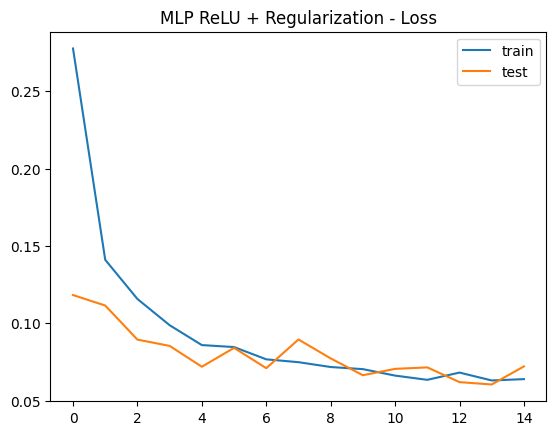

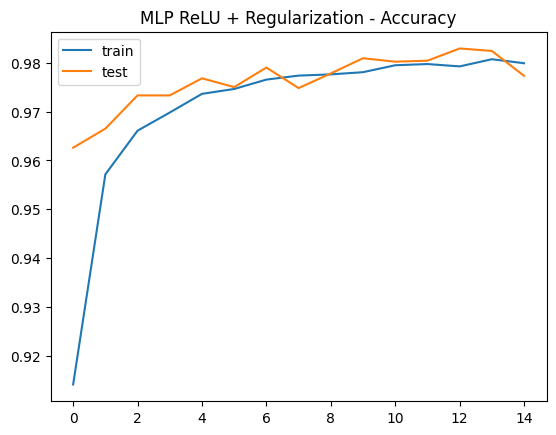

In [7]:
plt.plot(tr_loss1, label="train")
plt.plot(te_loss1, label="test")
plt.legend()
plt.title("MLP ReLU + Regularization - Loss")
plt.show()

plt.plot(tr_acc1, label="train")
plt.plot(te_acc1, label="test")
plt.legend()
plt.title("MLP ReLU + Regularization - Accuracy")
plt.show()

MLP không regularization + Sigmoid version

In [8]:
class MLP_ReLU_NoReg(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(784, 512)
        self.fc2 = nn.Linear(512, 256)
        self.fc3 = nn.Linear(256, 128)
        self.fc4 = nn.Linear(128, 10)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = F.relu(self.fc3(x))
        return self.fc4(x)

class MLP_Sigmoid(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(784, 512)
        self.fc2 = nn.Linear(512, 256)
        self.fc3 = nn.Linear(256, 128)
        self.fc4 = nn.Linear(128, 10)
        self.dp = nn.Dropout(0.3)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        x = torch.sigmoid(self.fc1(x)); x = self.dp(x)
        x = torch.sigmoid(self.fc2(x)); x = self.dp(x)
        x = torch.sigmoid(self.fc3(x))
        return self.fc4(x)

Train NoReg + Sigmoid

In [9]:
mlp_noreg = MLP_ReLU_NoReg()
tr_loss2, te_loss2, tr_acc2, te_acc2 = train_model(mlp_noreg, train_loader, test_loader, epochs=15)

Epoch 1/15 | Train acc 0.9311 | Test acc 0.9672
Epoch 2/15 | Train acc 0.9710 | Test acc 0.9698
Epoch 3/15 | Train acc 0.9799 | Test acc 0.9732
Epoch 4/15 | Train acc 0.9833 | Test acc 0.9747
Epoch 5/15 | Train acc 0.9873 | Test acc 0.9802
Epoch 6/15 | Train acc 0.9885 | Test acc 0.9796
Epoch 7/15 | Train acc 0.9905 | Test acc 0.9804
Epoch 8/15 | Train acc 0.9918 | Test acc 0.9786
Epoch 9/15 | Train acc 0.9916 | Test acc 0.9814
Epoch 10/15 | Train acc 0.9933 | Test acc 0.9815
Epoch 11/15 | Train acc 0.9940 | Test acc 0.9800
Epoch 12/15 | Train acc 0.9937 | Test acc 0.9810
Epoch 13/15 | Train acc 0.9950 | Test acc 0.9796
Epoch 14/15 | Train acc 0.9951 | Test acc 0.9830
Epoch 15/15 | Train acc 0.9956 | Test acc 0.9799


In [10]:
mlp_sig = MLP_Sigmoid()
tr_loss3, te_loss3, tr_acc3, te_acc3 = train_model(mlp_sig, train_loader, test_loader, epochs=15, wd=1e-4)

Epoch 1/15 | Train acc 0.8547 | Test acc 0.9462
Epoch 2/15 | Train acc 0.9513 | Test acc 0.9667
Epoch 3/15 | Train acc 0.9613 | Test acc 0.9687
Epoch 4/15 | Train acc 0.9672 | Test acc 0.9707
Epoch 5/15 | Train acc 0.9701 | Test acc 0.9743
Epoch 6/15 | Train acc 0.9719 | Test acc 0.9778
Epoch 7/15 | Train acc 0.9734 | Test acc 0.9782
Epoch 8/15 | Train acc 0.9755 | Test acc 0.9778
Epoch 9/15 | Train acc 0.9763 | Test acc 0.9771
Epoch 10/15 | Train acc 0.9759 | Test acc 0.9744
Epoch 11/15 | Train acc 0.9773 | Test acc 0.9802
Epoch 12/15 | Train acc 0.9767 | Test acc 0.9804
Epoch 13/15 | Train acc 0.9782 | Test acc 0.9783
Epoch 14/15 | Train acc 0.9780 | Test acc 0.9795
Epoch 15/15 | Train acc 0.9790 | Test acc 0.9799


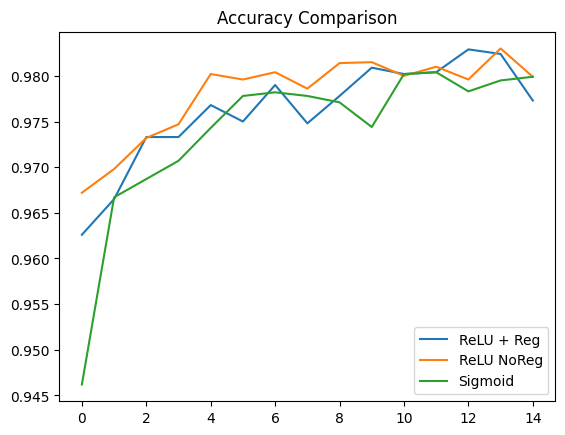

In [11]:
plt.plot(te_acc1, label="ReLU + Reg")
plt.plot(te_acc2, label="ReLU NoReg")
plt.plot(te_acc3, label="Sigmoid")
plt.legend()
plt.title("Accuracy Comparison")
plt.show()

CNN

In [12]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 16, 3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, 3, padding=1)
        self.pool = nn.MaxPool2d(2,2)
        self.fc1 = nn.Linear(32*7*7, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = self.pool(x)
        x = F.relu(self.conv2(x))
        x = self.pool(x)
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        return self.fc2(x)

In [13]:
cnn = SimpleCNN()
cnn_tr_loss, cnn_te_loss, cnn_tr_acc, cnn_te_acc = train_model(
    cnn, train_loader, test_loader, epochs=5, lr=1e-3, wd=1e-4
)

Epoch 1/5 | Train acc 0.9505 | Test acc 0.9815
Epoch 2/5 | Train acc 0.9841 | Test acc 0.9883
Epoch 3/5 | Train acc 0.9892 | Test acc 0.9901
Epoch 4/5 | Train acc 0.9912 | Test acc 0.9885
Epoch 5/5 | Train acc 0.9926 | Test acc 0.9896


Visualize activation

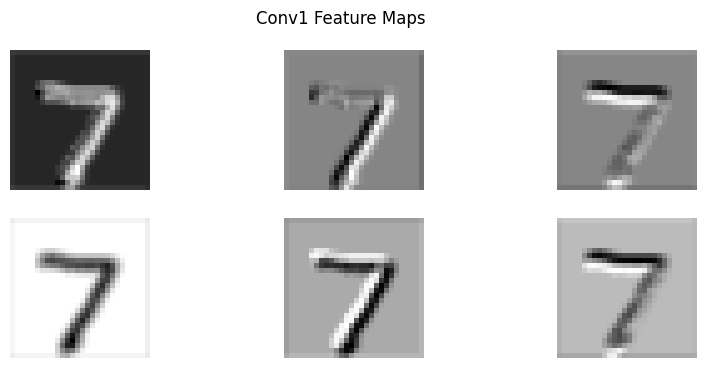

In [14]:
images, labels = next(iter(test_loader))
images = images.to(device)

acts = {}

def hook(name):
    def fn(m, inp, out):
        acts[name] = out.detach().cpu()
    return fn

h1 = cnn.conv1.register_forward_hook(hook("c1"))
h2 = cnn.conv2.register_forward_hook(hook("c2"))

cnn.eval()
with torch.no_grad():
    _ = cnn(images)

h1.remove()
h2.remove()

act1 = acts["c1"]
act2 = acts["c2"]

plt.figure(figsize=(10,4))
for i in range(6):
    plt.subplot(2,3,i+1)
    plt.imshow(act1[0, i], cmap="gray")
    plt.axis("off")
plt.suptitle("Conv1 Feature Maps")
plt.show()